<a href="https://colab.research.google.com/github/avikds/Qubit-State-Explorer/blob/main/Qubit_State_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build a Qubit State Explorer

This notebook explores how different single-qubit quantum gates affect the state of a qubit.

The user can choose one of the following gates:

- **X Gate**
- **Y Gate**
- **Z Gate**
- **H (Hadamard) Gate**
- **RY Gate** — requires an angle `θ` in radians

For the selected gate, the notebook will:

1. Apply the gate to a qubit initially in $|0\rangle$.
2. Display the resulting quantum circuit.
3. Display the final qubit state on the Bloch Sphere.
4. Show the probabilities of measuring $|0\rangle$ and $|1\rangle$.

## 1. Install the Required Libraries

In [22]:
!pip -q install qiskit qiskit-aer matplotlib pylatexenc

## 2. Import Qiskit and Visualization Tools

In [23]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display

## 3. Choose a Quantum Gate

The qubit starts in the computational basis state $|0\rangle$.

Enter one of the following choices:

- `X`
- `Y`
- `Z`
- `H`
- `RY`

For `RY`, enter the rotation angle $\theta$ in **radians**.

In [24]:
# Qubit State Explorer

print("Available Gates")
print("1. X Gate")
print("2. Y Gate")
print("3. Z Gate")
print("4. H (Hadamard) Gate")
print("5. RY Gate")

choice_map = {
    "1": "X",
    "2": "Y",
    "3": "Z",
    "4": "H",
    "5": "RY",
    "X": "X",
    "Y": "Y",
    "Z": "Z",
    "H": "H",
    "RY": "RY"
}

while True:
    choice = input("\nChoose a gate: ").strip().upper()
    if choice in choice_map:
        gate = choice_map[choice]
        break
    print("Invalid choice. Please enter 1-5 or X, Y, Z, H, or RY.")

theta = None

if gate == "RY":
    while True:
        try:
            theta = float(input("Enter the rotation angle θ in radians: ").strip())
            break
        except ValueError:
            print("Invalid angle. Please enter a number, for example 0, 1.57, or 3.1416.")

print(f"\nSelected Gate: {gate}")
if theta is not None:
    print(f"θ = {theta:.6f} radians")

Available Gates
1. X Gate
2. Y Gate
3. Z Gate
4. H (Hadamard) Gate
5. RY Gate

Choose a gate: RY
Enter the rotation angle θ in radians: 45

Selected Gate: RY
θ = 45.000000 radians


## 4. Create the Quantum Circuit and Apply the Selected Gate

A one-qubit circuit is created. The selected gate is then applied to qubit `0`.

Quantum Circuit


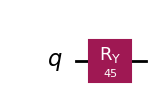

In [25]:
# Create a quantum circuit with 1 qubit
qc = QuantumCircuit(1)

# Apply the selected gate
if gate == "X":
    qc.x(0)
elif gate == "Y":
    qc.y(0)
elif gate == "Z":
    qc.z(0)
elif gate == "H":
    qc.h(0)
elif gate == "RY":
    qc.ry(theta, 0)

print("Quantum Circuit")
display(qc.draw("mpl"))

## 5. Calculate the Final State

The final state is obtained using Qiskit's `Statevector.from_instruction()`.

This lets us inspect the state **before measurement**, which is important for the Bloch Sphere representation.

In [26]:
# Calculate the final statevector
state = Statevector.from_instruction(qc)

print("Final Statevector:")
print(state)

Final Statevector:
Statevector([-0.87330464+0.j, -0.48717451+0.j],
            dims=(2,))


## 6. Bloch Sphere Representation

The Bloch Sphere gives a geometric representation of a single-qubit state. The final state of the circuit is plotted below.

Bloch Sphere


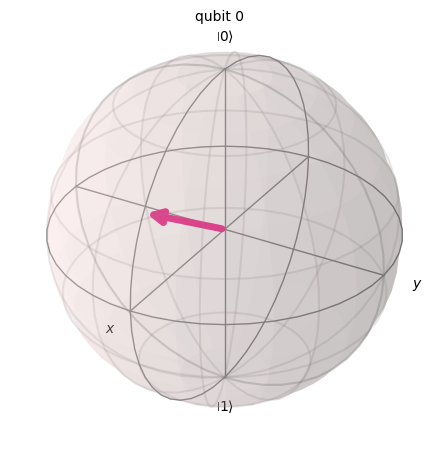

In [27]:
print("Bloch Sphere")
display(plot_bloch_multivector(state))

## 7. Measurement Probabilities

The probabilities of measuring $|0\rangle$ and $|1\rangle$ are obtained directly from the final statevector.

For a one-qubit state

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,
$$

the measurement probabilities are $|\alpha|^2$ and $|\beta|^2$.

Measurement Probabilities
P(|0⟩) = 0.7627
P(|1⟩) = 0.2373


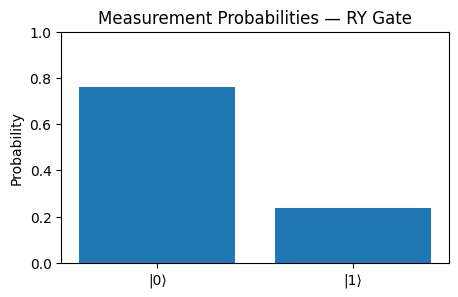

In [28]:
# Calculate measurement probabilities
probs = state.probabilities()

print("Measurement Probabilities")
print(f"P(|0⟩) = {probs[0]:.4f}")
print(f"P(|1⟩) = {probs[1]:.4f}")

# Visualize the probabilities
plt.figure(figsize=(5, 3))
plt.bar(["|0⟩", "|1⟩"], probs)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title(f"Measurement Probabilities — {gate} Gate")
plt.show()

## 8. Interpretation

The outputs above give three complementary views of the same final qubit state:

- **Quantum circuit:** shows the gate applied to the qubit.
- **Bloch Sphere:** shows the geometric location of the final single-qubit state.
- **Measurement probabilities:** show the likelihood of obtaining `0` or `1` when the qubit is measured in the computational basis.

For the `RY` gate, changing $\theta$ changes the qubit continuously and therefore changes the measurement probabilities.